<a href="https://colab.research.google.com/github/viktoria1user/Math_modelling/blob/main/Graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.special import ellipk, ellipe
from numpy.polynomial.legendre import leggauss
from time import perf_counter
from pathlib import Path

try:
    import plotly.graph_objects as go
except Exception:
    go = None

mu0 = 4 * np.pi * 1e-7
ASSETS = Path("mutual_inductance_presentation_fixed_assets")

In [ ]:
PALETTE = {
    "blue": "#3366FF",
    "red": "#E64B7A",
    "orange": "#FF9F1C",
    "green": "#22B573",
    "purple": "#7E57C2",
    "gray": "#6D7280",
    "dark": "#19202A",
    "paper": "#F7F9FC",
    "grid": "#DCE4F2",
    "light_blue": "#DCE8FF",
    "light_red": "#FDE1EB",
    "light_green": "#E2F6EC",
    "light_orange": "#FFF1DA",
}

def setup_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "#B9C4D4",
        "axes.linewidth": 1.0,
        "axes.labelsize": 13.5,
        "axes.labelcolor": PALETTE["dark"],
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "xtick.color": PALETTE["dark"],
        "ytick.color": PALETTE["dark"],
        "grid.color": PALETTE["grid"],
        "grid.alpha": 0.95,
        "grid.linewidth": 0.9,
        "grid.linestyle": "--",
        "font.family": "DejaVu Sans",
        "legend.fontsize": 11,
        "savefig.dpi": 220,
    })

def apply_header(fig, title, subtitle="", right_panel=False):
    fig.suptitle(
        title, x=0.08, y=0.975,
        ha="left", va="top",
        fontsize=20, fontweight="bold", color=PALETTE["dark"]
    )
    if subtitle:
        fig.text(
            0.08, 0.925, subtitle,
            ha="left", va="top",
            fontsize=11.5, color=PALETTE["gray"]
        )
    if right_panel:
        fig.subplots_adjust(left=0.08, right=0.74, top=0.86, bottom=0.12)
    else:
        fig.subplots_adjust(left=0.08, right=0.97, top=0.86, bottom=0.12)

def style_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="major")
    ax.grid(True, which="minor", alpha=0.35)
    if ax.get_xscale() == "linear":
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if ax.get_yscale() == "linear":
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def side_box(fig, text, x, y, fc="white"):
    fig.text(
        x, y, text,
        ha="left", va="top",
        fontsize=10.6, color=PALETTE["dark"],
        bbox=dict(boxstyle="round,pad=0.6", fc=fc, ec="#D5DEEB", lw=1.0)
    )

def side_chip(fig, text, x, y, color):
    fig.text(
        x, y, text,
        ha="left", va="center",
        fontsize=10.2, color=PALETTE["dark"],
        bbox=dict(boxstyle="round,pad=0.35", fc=color, ec="none")
    )

def save_current(fig, fig_name):
    ASSETS.mkdir(exist_ok=True, parents=True)
    path = ASSETS / fig_name
    fig.savefig(path, bbox_inches="tight")
    return path

In [ ]:
def circle(R, z0=0.0, N=240, center=(0.0, 0.0)):
    t = np.linspace(0, 2 * np.pi, N, endpoint=False)
    x = center[0] + R * np.cos(t)
    y = center[1] + R * np.sin(t)
    z = np.full(N, z0)
    return np.column_stack([x, y, z])

def ellipse_by_area(area_ref, aspect=2.1, z0=0.0, N=240, center=(0.0, 0.0)):
    b = np.sqrt(area_ref / (np.pi * aspect))
    a = aspect * b
    t = np.linspace(0, 2 * np.pi, N, endpoint=False)
    x = center[0] + a * np.cos(t)
    y = center[1] + b * np.sin(t)
    z = np.full(N, z0)
    return np.column_stack([x, y, z]), a, b

def square_by_area(area_ref, z0=0.0, N=240, center=(0.0, 0.0)):
    if N % 4 != 0:
        raise ValueError("Для квадратного контура требуется N, кратное 4.")
    a = np.sqrt(area_ref)
    n = N // 4
    cx, cy = center
    side = np.linspace(-a / 2, a / 2, n, endpoint=False)
    top = np.column_stack([cx + side, np.full(n, cy + a / 2), np.full(n, z0)])
    right = np.column_stack([np.full(n, cx + a / 2), cy + side, np.full(n, z0)])
    bottom = np.column_stack([cx + side[::-1], np.full(n, cy - a / 2), np.full(n, z0)])
    left = np.column_stack([np.full(n, cx - a / 2), cy + side[::-1], np.full(n, z0)])
    return np.vstack([top, right, bottom, left]), a

def rotate_contour_x(C, angle_rad, center=None):
    if center is None:
        center = C.mean(axis=0)
    center = np.asarray(center)
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    Rm = np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s, c],
    ])
    return (C - center) @ Rm.T + center

def close_contour(C):
    return np.vstack([C, C[0]])

def segment_data(C):
    C_next = np.roll(C, -1, axis=0)
    dl = C_next - C
    mid = 0.5 * (C_next + C)
    return mid, dl

In [ ]:
def neumann_midpoint(C1, C2, eps=1e-12):
    mid1, dl1 = segment_data(C1)
    mid2, dl2 = segment_data(C2)
    diff = mid1[:, None, :] - mid2[None, :, :]
    r = np.linalg.norm(diff, axis=2)
    dot = dl1 @ dl2.T
    mask = r > eps
    return mu0 / (4 * np.pi) * np.sum(dot[mask] / r[mask])

def neumann_analytical(R1, R2, d):
    k2 = 4 * R1 * R2 / ((R1 + R2) ** 2 + d ** 2)
    k = np.sqrt(k2)
    K = ellipk(k2)
    E = ellipe(k2)
    return mu0 * np.sqrt(R1 * R2) * ((2 / k - k) * K - (2 / k) * E)

def neumann_gauss_circles(R1, R2, d, nq=28):
    x, w = leggauss(nq)
    phi = np.pi * (x + 1.0)
    ww = np.pi * w
    phi1, phi2 = np.meshgrid(phi, phi, indexing="ij")
    W = np.outer(ww, ww)
    denom = np.sqrt(R1**2 + R2**2 + d**2 - 2 * R1 * R2 * np.cos(phi1 - phi2))
    integrand = (R1 * R2 * np.cos(phi1 - phi2)) / denom
    return mu0 / (4 * np.pi) * np.sum(W * integrand)

In [ ]:
def quick_validation(R=0.10, d=0.05, N=240):
    C1 = circle(R=R, z0=0.0, N=N)
    C2 = circle(R=R, z0=d, N=N)
    M_num = neumann_midpoint(C1, C2)
    M_anal = neumann_analytical(R, R, d)
    err = abs(M_num - M_anal) / abs(M_anal) * 100
    print("Проверка на коаксиальных круглых контурах")
    print(f"R1 = R2 = {R:.3f} м, d = {d:.3f} м, N = {N}")
    print(f"Численный расчёт      : {M_num * 1e6:.6f} мкГн")
    print(f"Аналитическая формула : {M_anal * 1e6:.6f} мкГн")
    print(f"Относительная ошибка  : {err:.5f} %")

In [ ]:
def plot_convergence(R1=0.10, R2=0.10, d=0.05, N_values=None, save=True):
    if N_values is None:
        N_values = [8, 12, 16, 24, 32, 48, 64, 96, 128, 160, 220]
    M_ref = neumann_analytical(R1, R2, d)
    err_mid, err_gauss = [], []
    time_mid, time_gauss = [], []
    for N in N_values:
        C1 = circle(R1, z0=0.0, N=N)
        C2 = circle(R2, z0=d, N=N)

        t0 = perf_counter()
        M_mid = neumann_midpoint(C1, C2)
        time_mid.append(perf_counter() - t0)

        t0 = perf_counter()
        M_g = neumann_gauss_circles(R1, R2, d, nq=min(N, 64))
        time_gauss.append(perf_counter() - t0)

        err_mid.append(abs(M_mid - M_ref) / abs(M_ref) * 100)
        err_gauss.append(abs(M_g - M_ref) / abs(M_ref) * 100)

    def first_below(values, threshold=1.0):
        for n, v in zip(N_values, values):
            if v < threshold:
                return n, v
        return None, None

    n_mid, _ = first_below(err_mid, 1.0)
    n_g, _ = first_below(err_gauss, 1.0)

    fig, ax = plt.subplots(figsize=(13.2, 7.8))
    apply_header(
        fig,
        "Сходимость численных методов для расчёта взаимной индуктивности",
        "Эталон — аналитическая формула для двух коаксиальных круглых контуров.",
        right_panel=True,
    )
    ax.loglog(N_values, err_mid, "-o", color=PALETTE["blue"], label="Метод средних прямоугольников")
    ax.loglog(N_values, err_gauss, "-s", color=PALETTE["red"], label="Гауссова квадратура")
    ax.axhline(1.0, color=PALETTE["orange"], linestyle="--", linewidth=1.8, label="Порог 1%")
    ax.fill_between(N_values, 1e-6, 1.0, color=PALETTE["light_green"], alpha=0.55)
    style_axes(ax, "Число узлов N", "Относительная погрешность, %")
    ax.legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.96)

    side_box(
        fig,
        "Ключевой вывод:\n\n"
        f"• Прямоугольники опускаются ниже 1% примерно при N ≈ {n_mid}.\n"
        f"• Гаусс достигает того же уровня уже при N ≈ {n_g}.\n\n"
        "Одинаковая точность достигается существенно меньшим числом узлов.",
        0.77, 0.79, fc=PALETTE["paper"]
    )
    side_box(
        fig,
        "Зеленая зона соответствует ошибке ниже 1%. \nЭто область практически приемлемой точности.",
        0.77, 0.47, fc="#F5FBF7"
    )

    if save:
        save_current(fig, "01_convergence.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(13.2, 7.8))
    apply_header(
        fig,
        "Сравнение быстродействия численных методов",
        "Абсолютные времена зависят от компьютера, но относительное преимущество методов сохраняется.",
        right_panel=True,
    )
    ax.loglog(N_values, time_mid, "-o", color=PALETTE["blue"], label="Метод средних прямоугольников")
    ax.loglog(N_values, time_gauss, "-s", color=PALETTE["red"], label="Гауссова квадратура")
    ax.fill_between(N_values, np.minimum(time_mid, time_gauss), np.maximum(time_mid, time_gauss),
                    color=PALETTE["light_blue"], alpha=0.28)
    style_axes(ax, "Число узлов N", "Время расчёта одного значения M, с")
    ax.legend(loc="upper left", frameon=True, fancybox=True, framealpha=0.96)

    side_box(
        fig,
        "Чем ниже кривая, тем быстрее вычисляется одно значение M.",
        0.77, 0.79, fc=PALETTE["paper"]
    )


    if save:
        save_current(fig, "02_speed.png")
    plt.show()

def plot_M_vs_distance(R1=0.10, R2=0.10, N=260, save=True):
    distances = np.linspace(0.01, 0.30, 65)
    M_values = []
    for d in distances:
        C1 = circle(R1, z0=0.0, N=N)
        C2 = circle(R2, z0=d, N=N)
        M_values.append(neumann_midpoint(C1, C2) * 1e6)

    M_values = np.asarray(M_values)
    x_cm = distances * 100
    start_val, end_val = M_values[0], M_values[-1]
    drop = (1 - end_val / start_val) * 100

    fig, ax = plt.subplots(figsize=(13.2, 7.8))
    apply_header(
        fig,
        "Как взаимная индуктивность убывает при удалении контуров",
        "Два одинаковых круглых контуров радиуса 10 см. \nЦветные зоны показывают режимы сильной, промежуточной и слабой магнитной связи.",
        right_panel=True,
    )
    ax.axvspan(1, 8, color=PALETTE["light_green"], alpha=0.40)
    ax.axvspan(8, 18, color=PALETTE["light_orange"], alpha=0.30)
    ax.axvspan(18, 30, color=PALETTE["light_red"], alpha=0.22)
    ax.plot(x_cm, M_values, color=PALETTE["purple"], lw=3.3)
    ax.fill_between(x_cm, M_values, color=PALETTE["light_blue"], alpha=0.45)
    ax.scatter([x_cm[0], x_cm[-1]], [M_values[0], M_values[-1]], color=PALETTE["purple"], s=50, zorder=5)
    style_axes(ax, "Расстояние между контурами d, см", "Взаимная индуктивность M, мкГн")

    side_chip(fig, "Зелёная зона — сильная связь", 0.77, 0.82, PALETTE["light_green"])
    side_chip(fig, "Оранжевая зона — переходный режим", 0.77, 0.77, PALETTE["light_orange"])
    side_chip(fig, "Красная зона — слабая связь", 0.77, 0.72, PALETTE["light_red"])

    side_box(
        fig,
        "Ключевые числа:\n\n"
        f"• При d = 1 см: M ≈ {start_val:.3f} мкГн.\n"
        f"• При d = 30 см: M ≈ {end_val:.3f} мкГн.\n"
        f"• Общее уменьшение составляет примерно {drop:.1f}%.",
        0.77, 0.61, fc=PALETTE["paper"]
    )
    side_box(
        fig,
        "Физический смысл:\n\n"
        "При увеличении расстояния всё меньшая доля магнитного потока первого контура сцепляется со вторым, \nпоэтому взаимная индуктивность монотонно уменьшается.",
        0.77, 0.36, fc="#F7F8FC"
    )

    if save:
        save_current(fig, "03_M_vs_distance.png")
    plt.show()

def plot_M_vs_angle(R=0.10, d=0.05, N=240, save=True):
    angles = np.linspace(0.0, np.pi / 2, 61)
    M_values = []
    C1 = circle(R, z0=0.0, N=N)
    C2_base = circle(R, z0=d, N=N)
    center2 = np.array([0.0, 0.0, d])

    for angle in angles:
        C2 = rotate_contour_x(C2_base, angle, center=center2)
        M_values.append(neumann_midpoint(C1, C2) * 1e6)

    deg = np.degrees(angles)
    M_values = np.asarray(M_values)
    idx_max = int(np.argmax(M_values))
    key_idxs = [0, np.argmin(np.abs(deg - 45)), len(deg) - 1]

    fig, ax = plt.subplots(figsize=(13.2, 7.8))
    apply_header(
        fig,
        "Влияние взаимной ориентации контуров на магнитную связь:",
        "Второй контур поворачивается вокруг оси X, а расстояние между центрами фиксировано: d = 5 см.",
        right_panel=True,
    )
    ax.plot(deg, M_values, color=PALETTE["red"], lw=3.3)
    ax.fill_between(deg, M_values, color=PALETTE["light_red"], alpha=0.55)
    for v in [0, 30, 60, 90]:
        ax.axvline(v, color="#C9D2E3", lw=1.0, linestyle="--", zorder=0)
    ax.scatter(deg[key_idxs], M_values[key_idxs], color=PALETTE["red"], s=55, zorder=5)
    ax.scatter([deg[idx_max]], [M_values[idx_max]], color=PALETTE["orange"], s=70, zorder=6)
    style_axes(ax, "Угол поворота второй катушки θ, градусы", "Взаимная индуктивность M, мкГн")

    side_box(
        fig,
        "Ключевые значения:\n\n"
        f"• 0°: M ≈ {M_values[key_idxs[0]]:.3f} мкГн\n"
        f"• 45°: M ≈ {M_values[key_idxs[1]]:.3f} мкГн\n"
        f"• 90°: M ≈ {M_values[key_idxs[2]]:.3f} мкГн\n\n"
        f"Локальный максимум в этой модели наблюдается около {deg[idx_max]:.0f}°.",
        0.77, 0.80, fc=PALETTE["paper"]
    )
    side_box(
        fig,
        "Ориентация контуров влияет на то, какая часть магнитного потока первого контура проходит через второй. \nПоэтому M зависит не только от расстояния, но и от пространственного поворота.",
        0.77, 0.47, fc="#FDF7FA"
    )

    if save:
        save_current(fig, "04_M_vs_angle.png")
    plt.show()

def plot_M_vs_shape(R_ref=0.10, N=240, save=True):
    distances = np.linspace(0.01, 0.30, 55)
    area_ref = np.pi * R_ref**2

    M_circle = []
    M_square = []
    M_ellipse = []

    for d in distances:
        C1 = circle(R=R_ref, z0=0.0, N=N)
        C2_circle = circle(R=R_ref, z0=d, N=N)
        C2_square, _ = square_by_area(area_ref, z0=d, N=N)
        C2_ellipse, _, _ = ellipse_by_area(area_ref, aspect=2.1, z0=d, N=N)

        M_circle.append(neumann_midpoint(C1, C2_circle) * 1e6)
        M_square.append(neumann_midpoint(C1, C2_square) * 1e6)
        M_ellipse.append(neumann_midpoint(C1, C2_ellipse) * 1e6)

    x_cm = distances * 100
    M_circle = np.asarray(M_circle)
    M_square = np.asarray(M_square)
    M_ellipse = np.asarray(M_ellipse)
    idx_5cm = np.argmin(np.abs(x_cm - 5.0))

    fig, ax = plt.subplots(figsize=(13.2, 7.8))
    apply_header(
        fig,
        "Как форма второго контура влияет на взаимную индуктивность",
        "Все контуры выбраны с одинаковой площадью, чтобы сравнение было честным.",
        right_panel=True,
    )
    ax.plot(x_cm, M_circle, color=PALETTE["blue"], label="Круг")
    ax.plot(x_cm, M_square, color=PALETTE["orange"], label="Квадрат")
    ax.plot(x_cm, M_ellipse, color=PALETTE["green"], label="Эллипс той же площади")
    style_axes(ax, "Расстояние между центрами контуров d, см", "Взаимная индуктивность M, мкГн")
    ax.legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.96)

    side_box(
        fig,
        "Сравнение при d ≈ 5 см:\n\n"
        f"• Круг: M ≈ {M_circle[idx_5cm]:.3f} мкГн\n"
        f"• Квадрат: M ≈ {M_square[idx_5cm]:.3f} мкГн\n"
        f"• Эллипс: M ≈ {M_ellipse[idx_5cm]:.3f} мкГн",
        0.77, 0.79, fc=PALETTE["paper"]
    )
    side_box(
        fig,
        "Вывод по форме:\n\n"
        "Даже при одинаковой площади геометрия контура меняет распределение тока в пространстве, \nа значит влияет и на величину взаимной индуктивности.",
        0.77, 0.50, fc="#F5FBF7"
    )

    if save:
        save_current(fig, "05_M_vs_shape.png")
    plt.show()

In [ ]:
def plot_contours_3d_presentation(C1, C2, save=True):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    C1c = close_contour(C1)
    C2c = close_contour(C2)
    z1 = np.mean(C1[:, 2])
    z2 = np.mean(C2[:, 2])
    d_cm = abs(z2 - z1) * 100

    fig = plt.figure(figsize=(11.4, 8.8))
    ax = fig.add_subplot(111, projection="3d")
    fig.suptitle(
        "Пространственная модель двух контуров",
        x=0.08, y=0.97, ha="left", va="top",
        fontsize=20, fontweight="bold", color=PALETTE["dark"]
    )
    fig.text(
        0.08, 0.93,
        "Показаны оба контура, межцентровое расстояние d и условные линии магнитного сцепления.",
        ha="left", va="top", fontsize=11.2, color=PALETTE["gray"]
    )
    fig.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.05)

    ax.plot(C1c[:, 0], C1c[:, 1], C1c[:, 2], color=PALETTE["blue"], lw=4.0, label="Контур 1")
    ax.plot(C2c[:, 0], C2c[:, 1], C2c[:, 2], color=PALETTE["red"], lw=4.0, label="Контур 2")
    ax.plot([0, 0], [0, 0], [z1, z2], linestyle="--", color=PALETTE["gray"], lw=2.0)
    ax.scatter([0, 0], [0, 0], [z1, z2], color=PALETTE["dark"], s=42)

    for ang in np.linspace(0, 2*np.pi, 8, endpoint=False):
        x = 0.06 * np.cos(ang)
        y = 0.06 * np.sin(ang)
        z = np.linspace(z1, z2, 40)
        bend = 0.015 * np.sin(np.linspace(0, np.pi, 40))
        ax.plot(
            x + bend*np.cos(ang),
            y + bend*np.sin(ang),
            z,
            color=PALETTE["green"],
            alpha=0.42,
            lw=1.4
        )

    ax.text(0.012, 0.0, (z1 + z2) / 2, f"d = {d_cm:.1f} см", fontsize=11, color=PALETTE["dark"])
    ax.set_xlabel("X, м", labelpad=12)
    ax.set_ylabel("Y, м", labelpad=12)
    ax.set_zlabel("Z, м", labelpad=12)
    ax.legend(loc="upper left")
    ax.view_init(elev=24, azim=42)
    ax.set_box_aspect((1, 1, 0.85))

    if save:
        save_current(fig, "06_static_3d.png")
    plt.show()

In [ ]:
def coil_plane_surface(R, z0, n_r=20, n_t=70):
    r = np.linspace(0, R, n_r)
    t = np.linspace(0, 2*np.pi, n_t)
    rr, tt = np.meshgrid(r, t)
    x = rr * np.cos(tt)
    y = rr * np.sin(tt)
    z = np.full_like(x, z0)
    return x, y, z

def current_arrow_trace(C, color, step=14, name="Направление тока"):
    if go is None:
        return None
    p = C[step]
    v = C[(step + 5) % len(C)] - C[step]
    return go.Cone(
        x=[p[0]], y=[p[1]], z=[p[2]],
        u=[v[0]], v=[v[1]], w=[v[2]],
        sizemode="absolute", sizeref=0.03,
        anchor="tail",
        colorscale=[[0, color], [1, color]],
        showscale=False,
        name=name,
        hovertemplate=f"{name}<extra></extra>"
    )

def build_webgl_figure(C1, C2, title="Интерактивная 3D-модель контуров (WebGL)"):
    if go is None:
        raise ImportError("Для интерактивной 3D-визуализации установите plotly: pip install plotly")

    C1c = close_contour(C1)
    C2c = close_contour(C2)
    z1 = float(np.mean(C1[:, 2]))
    z2 = float(np.mean(C2[:, 2]))
    d_cm = abs(z2 - z1) * 100

    fig = go.Figure()

    for z0, rgba, label in [
        (z1, "rgba(51,102,255,0.12)", "Плоскость контура 1"),
        (z2, "rgba(230,75,122,0.12)", "Плоскость контура 2"),
    ]:
        xs, ys, zs = coil_plane_surface(0.1, z0)
        fig.add_trace(go.Surface(
            x=xs, y=ys, z=zs,
            opacity=0.20,
            showscale=False,
            hoverinfo="skip",
            name=label,
            colorscale=[[0, rgba], [1, rgba]],
        ))

    fig.add_trace(go.Scatter3d(
        x=C1c[:, 0], y=C1c[:, 1], z=C1c[:, 2],
        mode="lines", name="Контур 1",
        line=dict(color=PALETTE["blue"], width=10),
        hovertemplate="Контур 1<br>x=%{x:.3f} м<br>y=%{y:.3f} м<br>z=%{z:.3f} м<extra></extra>"
    ))
    fig.add_trace(go.Scatter3d(
        x=C2c[:, 0], y=C2c[:, 1], z=C2c[:, 2],
        mode="lines", name="Контур 2",
        line=dict(color=PALETTE["red"], width=10),
        hovertemplate="Контур 2<br>x=%{x:.3f} м<br>y=%{y:.3f} м<br>z=%{z:.3f} м<extra></extra>"
    ))
    fig.add_trace(go.Scatter3d(
        x=[0, 0], y=[0, 0], z=[z1, z2],
        mode="lines+markers", name="Межцентровое расстояние",
        line=dict(color=PALETTE["gray"], width=7, dash="dash"),
        marker=dict(size=4, color=PALETTE["dark"]),
        hovertemplate=f"Осевая линия<br>d = {d_cm:.1f} см<extra></extra>"
    ))

    for ang in np.linspace(0, 2*np.pi, 6, endpoint=False):
        x0 = 0.055 * np.cos(ang)
        y0 = 0.055 * np.sin(ang)
        z = np.linspace(z1, z2, 42)
        bend = 0.018 * np.sin(np.linspace(0, np.pi, 42))
        fig.add_trace(go.Scatter3d(
            x=x0 + bend*np.cos(ang),
            y=y0 + bend*np.sin(ang),
            z=z,
            mode="lines",
            showlegend=False,
            hoverinfo="skip",
            line=dict(color="rgba(34,181,115,0.55)", width=4)
        ))

    fig.add_trace(current_arrow_trace(C1, PALETTE["blue"], step=12, name="Направление тока 1"))
    fig.add_trace(current_arrow_trace(C2, PALETTE["red"], step=12, name="Направление тока 2"))

    fig.update_layout(
        template="plotly_white",
        title=dict(
            text=title + "<br><sup>Подсвечены оба контура, межцентровое расстояние d и условные линии магнитного сцепления.</sup>",
            x=0.03, xanchor="left"
        ),
        scene=dict(
            xaxis_title="Ось X, м",
            yaxis_title="Ось Y, м",
            zaxis_title="Ось Z, м",
            xaxis=dict(backgroundcolor="rgba(245,247,251,0.95)", gridcolor="#D8E0EC"),
            yaxis=dict(backgroundcolor="rgba(245,247,251,0.95)", gridcolor="#D8E0EC"),
            zaxis=dict(backgroundcolor="rgba(245,247,251,0.95)", gridcolor="#D8E0EC"),
            aspectmode="manual",
            aspectratio=dict(x=1.0, y=1.0, z=0.75),
            camera=dict(eye=dict(x=1.55, y=1.55, z=1.05))
        ),
        legend=dict(
            x=0.01, y=0.98,
            bgcolor="rgba(255,255,255,0.88)",
            bordercolor="#D8E0EC",
            borderwidth=1
        ),
        margin=dict(l=0, r=0, b=0, t=72),
        annotations=[
            dict(
                x=0.01, y=0.02, xref="paper", yref="paper",
                text=f"Текущая геометрия: R = 10 см, d = {d_cm:.1f} см.",
                showarrow=False, font=dict(size=12, color=PALETTE["gray"])
            )
        ]
    )
    return fig

def export_webgl_html(C1, C2, filename="07_coils_webgl.html"):
    fig = build_webgl_figure(C1, C2)
    path = ASSETS / filename
    path.parent.mkdir(exist_ok=True, parents=True)
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return path

def display_saved_assets():
    from IPython.display import display, Image, IFrame
    for f in [
        ASSETS / "01_convergence.png",
        ASSETS / "02_speed.png",
        ASSETS / "03_M_vs_distance.png",
        ASSETS / "04_M_vs_angle.png",
        ASSETS / "05_M_vs_shape.png",
        ASSETS / "06_static_3d.png",
    ]:
        if f.exists():
            display(Image(filename=str(f)))
    html = ASSETS / "07_coils_webgl.html"
    if html.exists():
        display(IFrame(src=str(html), width="100%", height=700))

Проверка на коаксиальных круглых контурах
R1 = R2 = 0.100 м, d = 0.050 м, N = 240
Численный расчёт      : 0.111255 мкГн
Аналитическая формула : 0.111261 мкГн
Относительная ошибка  : 0.00511 %


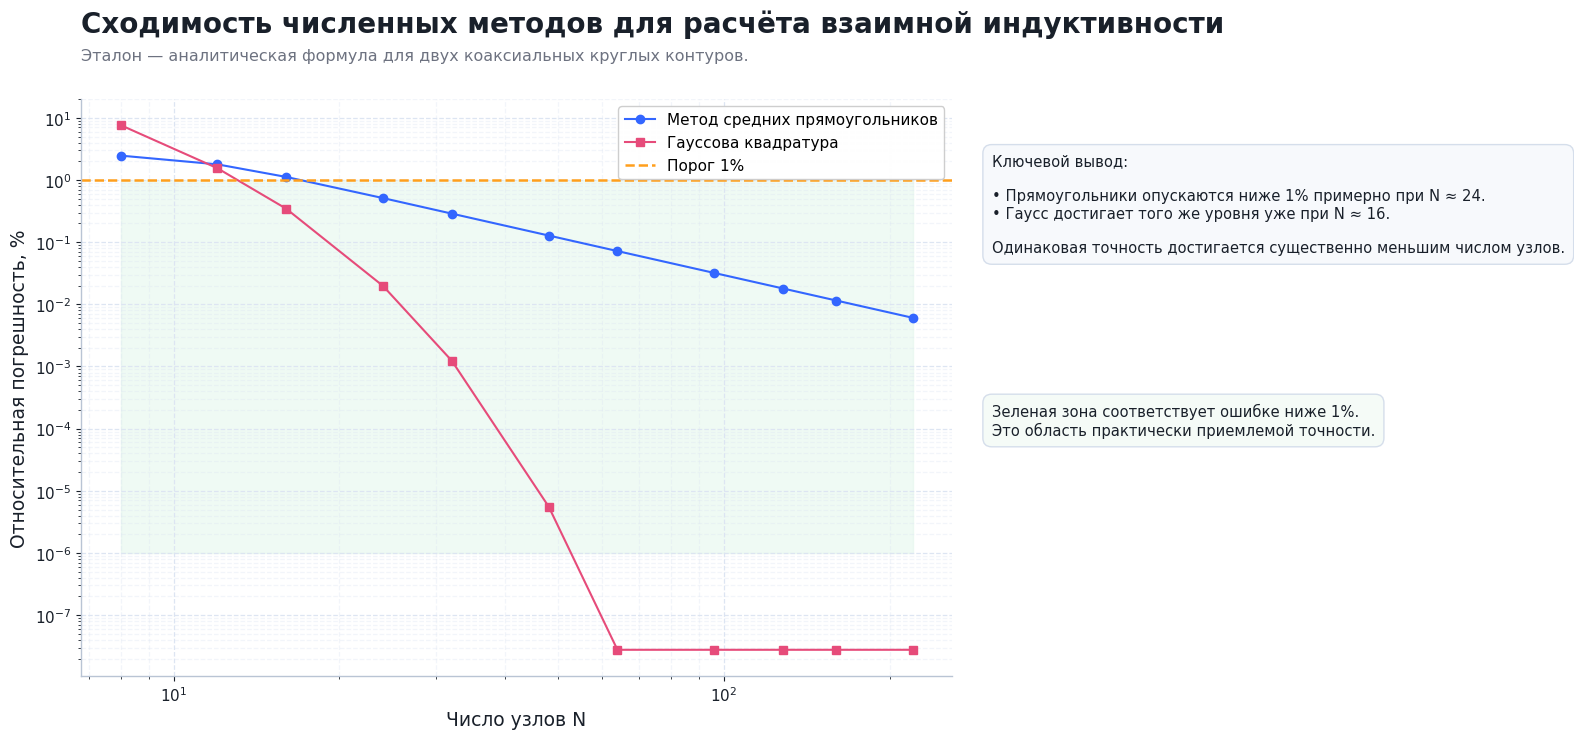

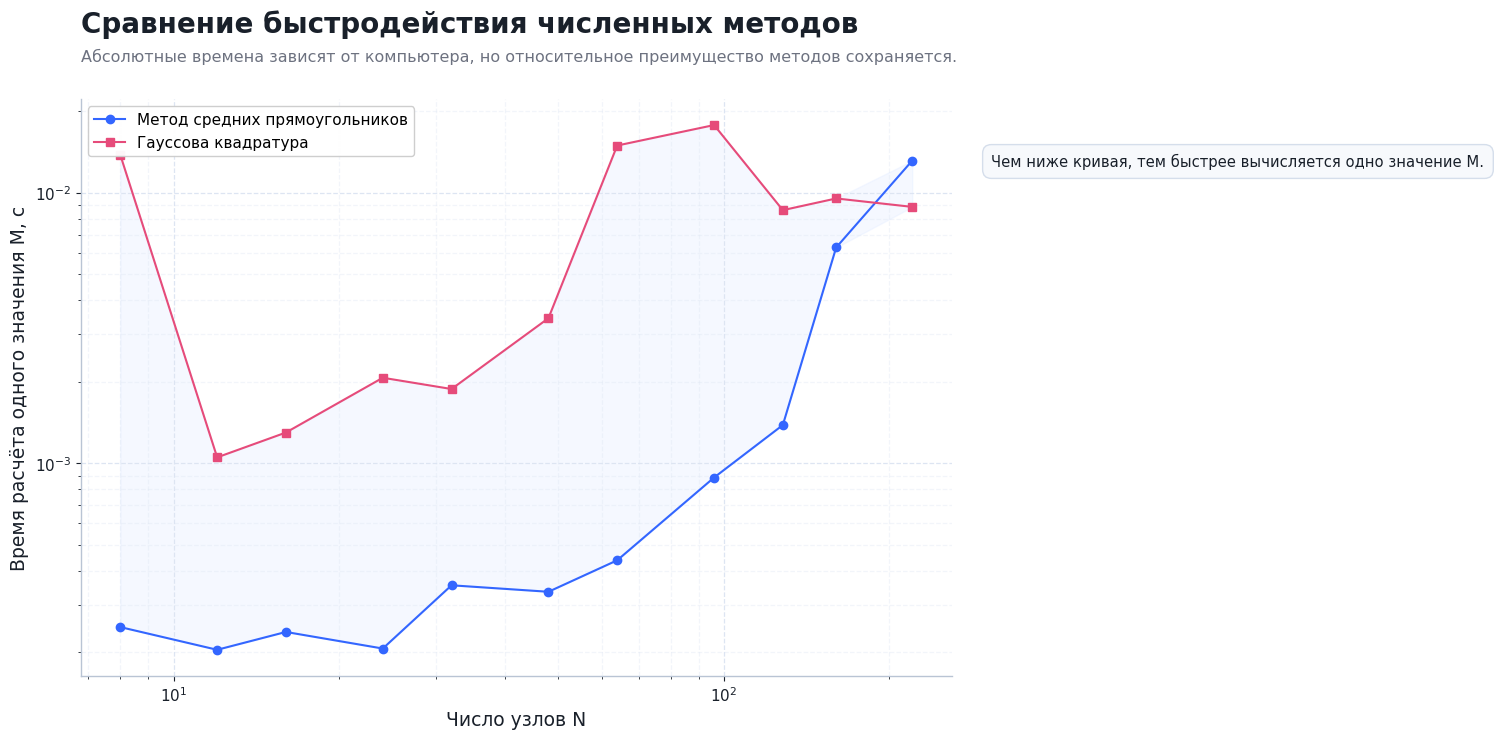

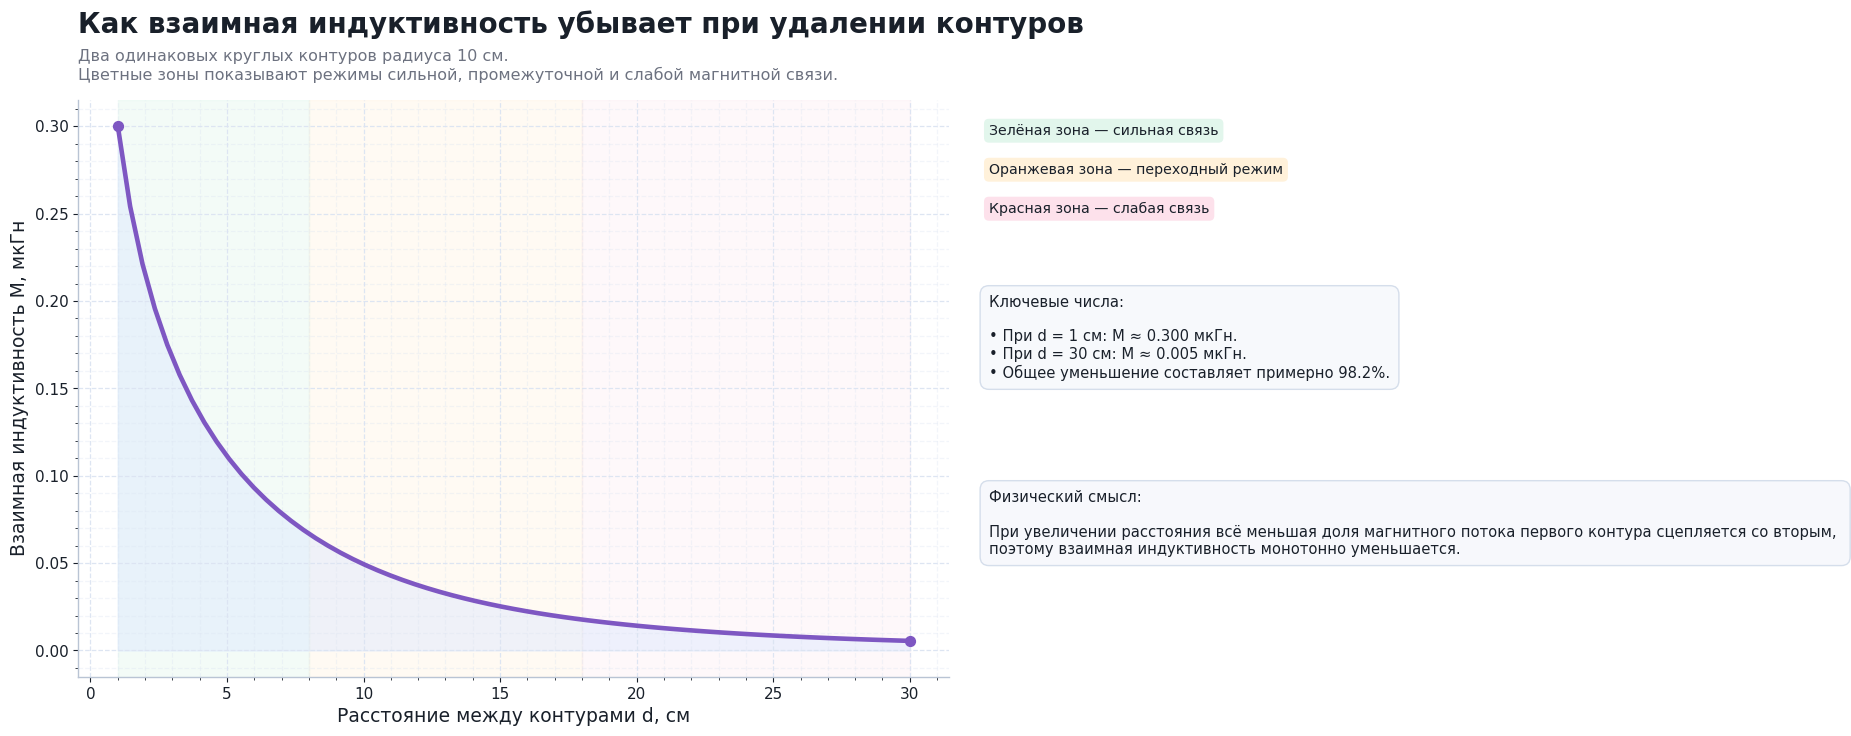

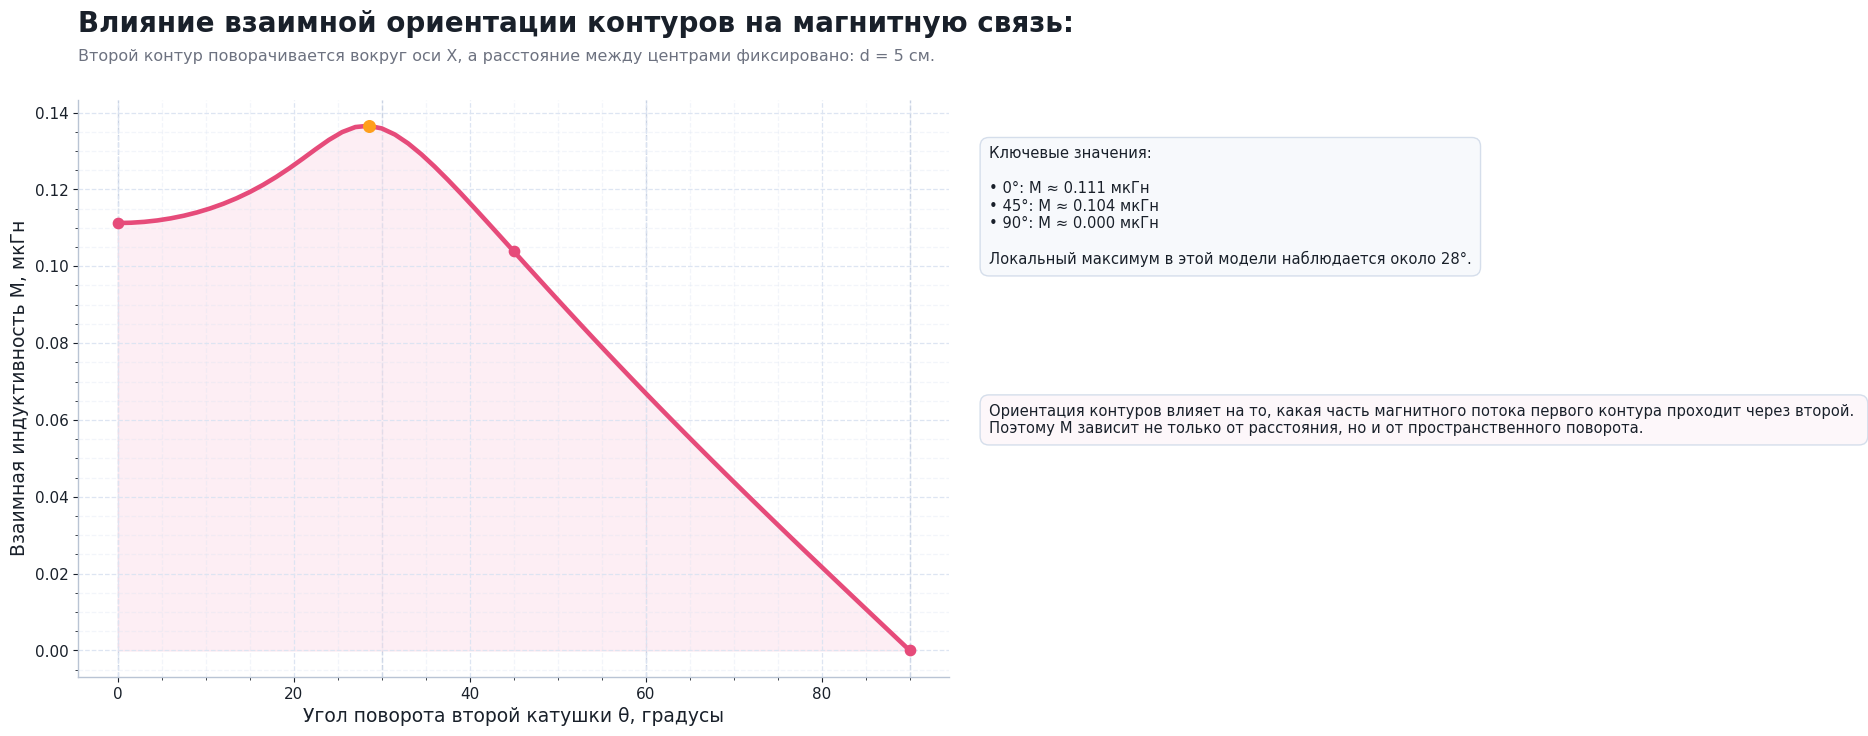

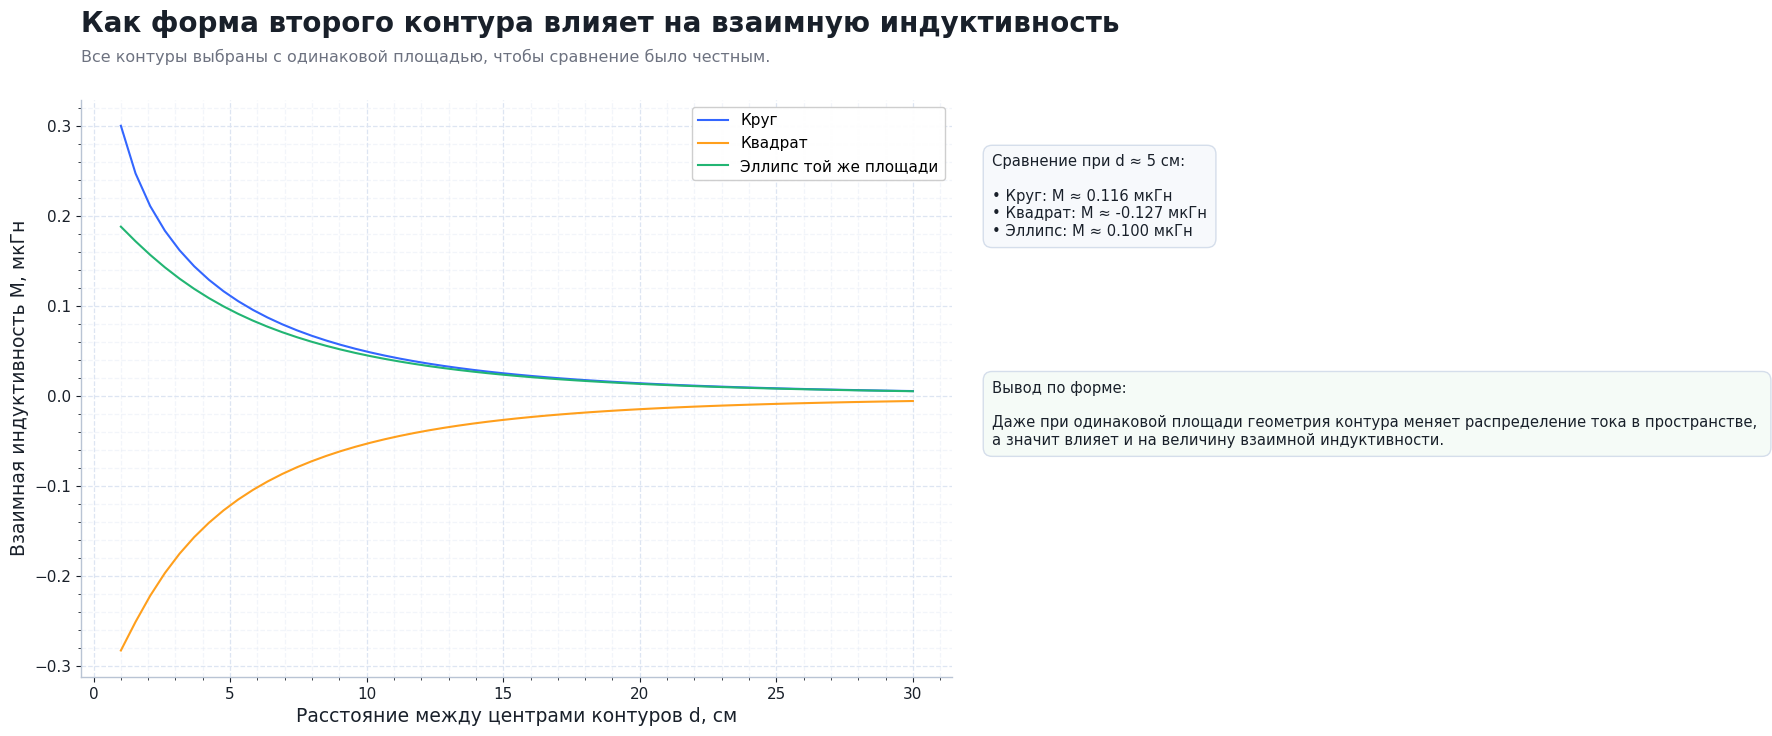

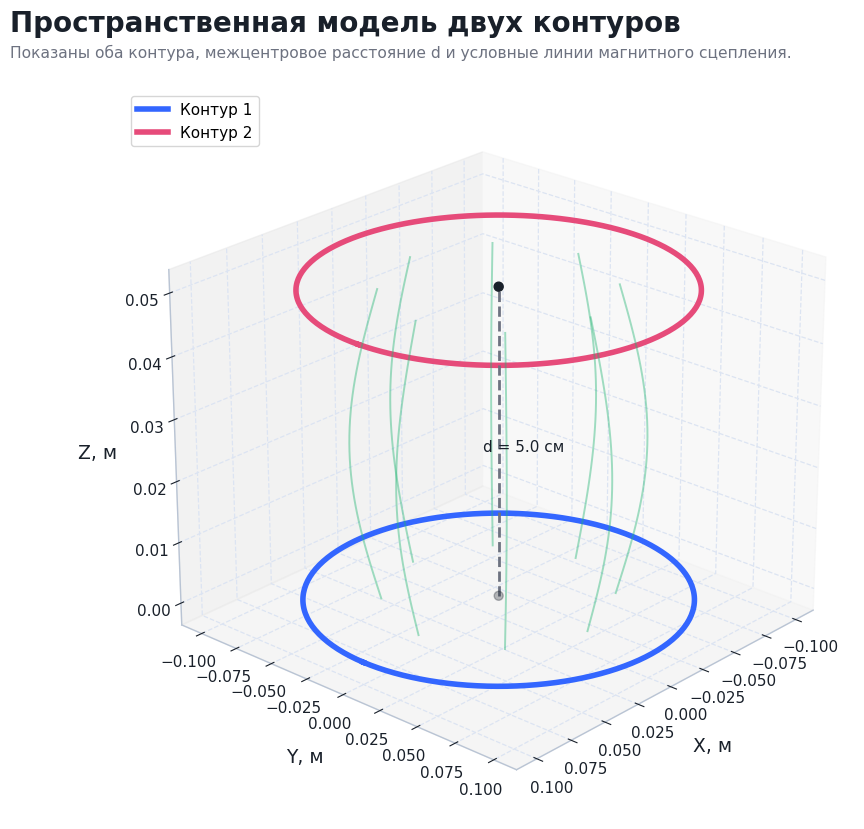

Интерактивная WebGL-визуализация сохранена: /content/mutual_inductance_presentation_fixed_assets/07_coils_webgl.html


In [ ]:
def generate_all():
    setup_style()

    ASSETS.mkdir(exist_ok=True, parents=True)

    quick_validation()

    plot_convergence()

    plot_M_vs_distance()

    plot_M_vs_angle()

    plot_M_vs_shape()

    C1 = circle(R=0.10, z0=0.0, N=260)

    C2 = circle(R=0.10, z0=0.05, N=260)

    plot_contours_3d_presentation(C1, C2)
    if go is not None:
        html_path = export_webgl_html(C1, C2)
        print(f"Интерактивная WebGL-визуализация сохранена: {html_path.resolve()}")
    else:
        print("Ошибка — HTML/WebGL-визуализация не была сохранена.")

if __name__ == "__main__":
    generate_all()